In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os

from numpy.ma.core import allclose
from numpy.typing import NDArray
from tqdm import tqdm

from src.particle import Particle
from src.fields import *
from src import utils


In [2]:

L = 10
BASE_NX = 100
BASE_NY = 100
Nx = L * BASE_NX
Ny = L * BASE_NY
num_particles = 4
num_steps = 20

is_occupied = np.full((Ny, Nx), fill_value=-1, dtype=np.int16)
chemA = np.full((Ny, Nx), fill_value=0.0, dtype=np.float32)
chemB = np.full((Ny, Nx), fill_value=0.0, dtype=np.float32)
positions = np.full(shape=(num_steps, num_particles, 2), fill_value=np.nan)

particles = []
collisions = []

#  Initialize particles with random positions, orientations, and radii
for i in range(1, num_particles + 1):
    x = Nx * np.random.rand()
    y = Ny * np.random.rand()
    theta = 2 * np.pi * np.random.rand()
    radius = 20.0 + 5. * np.random.rand()
    particles.append(Particle(i, x, y, theta, radius))
    utils.populate_is_occupied(radius=radius, xc=x, yc=y, id=i,
                               is_occupied=is_occupied, collisions=collisions)

    for particle in particles:
        # deposit_chemA(chemA, is_occupied, modify_fn=noise, scale=0.05)
        # deposit_chemA(chemA=chemA, is_occupied=is_occupied, modify_fn=noise, scale=10.0)
        deposit_chemA(chemA=chemA, is_occupied=is_occupied, modify_fn=weaken, factor=0.3)
        deposit_chemB(particle=particle, chemB=chemB)

# deposit_chemA(particle: Particle, chemA: NDArray, is_occupied: NDArray)

In [3]:

def folder():
    folder_name = 'snapshots'
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)
    return folder_name


def snap(is_occupied: NDArray,
         chemA: NDArray, chemB: NDArray,
         path: str, i: int) -> None:
    fig, ax = plt.subplots(1, 3)
    ax = ax.flatten()
    ax[0].set_title(f'at_{i}_is_occupied')
    ax[0].imshow(is_occupied)

    ax[1].set_title(f'at_{i}_chemA')
    ax[1].imshow(chemA)

    ax[2].set_title(f'at_{i}_chemB')
    ax[2].imshow(chemB)

    fig.savefig(os.path.join(path, 'at_{i}_snapshot.png'))
    plt.close(fig)


path = folder()
snap(is_occupied=is_occupied, chemA=chemA, chemB=chemB,
     path=path, i=i)

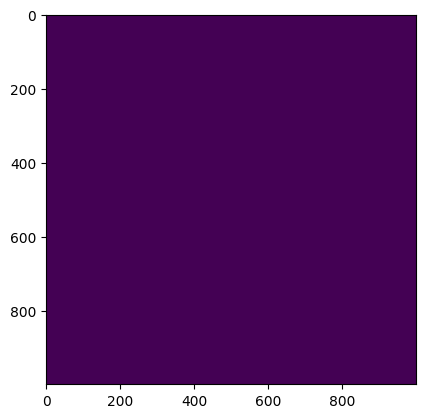

In [4]:
# for particle in particles:
#     deposit_chemA(particle=particle, chemA=chemA, is_occupied=is_occupied)
plt.imshow(chemA)

In [ ]:
for i in tqdm(range(num_steps)):

    # ---------------------------
    # 1. Reset geometry
    # ---------------------------
    is_occupied.fill(-1)
    collisions.clear()

    # ---------------------------
    # 2. Build occupancy (ALL particles)
    # ---------------------------
    for particle in particles:
        utils.populate_is_occupied(
            radius=particle.radius,
            xc=particle.x,
            yc=particle.y,
            id=particle.id,
            is_occupied=is_occupied,
            collisions=collisions
        )

    # ---------------------------
    # 3. Update fields (GLOBAL)
    # ---------------------------

    # Example: evolve instead of resetting (recommended)
    # chemA += diffusion / decay / etc (optional)

    # --- deposition / interaction ---
    # (customize this however you want)
    deposit_chemA(chemA, particles, is_occupied)
    deposit_chemB(chemB, particles, is_occupied)

    # ---------------------------
    # 4. Coarse-grain / smooth
    # ---------------------------
    avgA = utils.local_field_avg(chemA, R=10)
    avgB = utils.local_field_avg(chemB, R=10)

    # ---------------------------
    # 5. Compute gradients
    # ---------------------------
    dAdx, dAdy = utils.gradient(avgA)
    dBdx, dBdy = utils.gradient(avgB)

    # ---------------------------
    # 6. Update particle orientations
    # ---------------------------
    for particle in particles:
        particle.theta = utils.update_theta(
            particle=particle,
            particles=particles,
            gradAx=dAdx,
            gradAy=dAdy,
            gradBx=dBdx,
            gradBy=dBdy
        )

    # ---------------------------
    # 7. Move particles
    # ---------------------------
    for particle in particles:
        utils.move(particle, Nx, Ny)

    # ---------------------------
    # 8. Store positions
    # ---------------------------
    for particle in particles:
        positions[i, particle.id - 1, 0] = particle.x_unwrapped
        positions[i, particle.id - 1, 1] = particle.y_unwrapped

In [4]:
import numpy as np
def sum(a,b):
    return a+b
def test_sum(a,b,c,sum):
    d = sum(a,b)
    return np.allclose(d,c)

test_sum(1,2,2,sum)



False